# EEGMAT privacy preservation: Gaussian noise and feature masking

This notebook uses the clean 1-80 Hz, 19-channel EEG cache. It evaluates only:

1. Gaussian noise added to raw EEG windows.
2. Identity-informed feature masking.

Evaluation uses five outer subject folds. In every fold, transformation
parameters are learned only from the outer training subjects. Utility is tested
on unseen subjects. Privacy is measured within those same held-out subjects by
training an attacker on one condition and testing on the other condition.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

get_ipython().system(
    'pip -q install "scikit-learn>=1.4,<2" "scipy>=1.11" matplotlib'
)

Mounted at /content/drive


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

RANDOM_STATE = 42

BASE_DIR = Path("/content/drive/MyDrive/URV_Datasets/eegmat")
CACHE_DIR = BASE_DIR / "clean_eeg_only_cache"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RAW_WINDOWS_FILE = CACHE_DIR / "eegmat_clean_raw_windows_2s_250hz_1_80hz_balanced.npz"
METADATA_FILE = CACHE_DIR / "eegmat_clean_raw_windows_2s_250hz_1_80hz_balanced_metadata.csv"
FIXED_SPLITS_FILE = CACHE_DIR / "eegmat_clean_fixed_splits.json"

DETAIL_FILE = RESULTS_DIR / "eegmat_gaussian_feature_masking_detailed.csv"
SUMMARY_FILE = RESULTS_DIR / "eegmat_gaussian_feature_masking_summary.csv"
TRADEOFF_FILE = RESULTS_DIR / "eegmat_gaussian_feature_masking_tradeoff.csv"
RANKING_FILE = RESULTS_DIR / "eegmat_feature_masking_rankings.csv"
RUN_FILE = RESULTS_DIR / "eegmat_gaussian_feature_masking_run.json"
FIGURE_FILE = RESULTS_DIR / "eegmat_gaussian_feature_masking_tradeoff.png"

# Noise standard deviation as a multiple of the training-set channel SD.
NOISE_SIGMAS = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]

# Percentage of the most identity-informative features to mask.
MASK_PERCENTAGES = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80]

BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "low_gamma": (30.0, 45.0),
    "high_gamma": (45.0, 80.0),
}

print("Raw cache:", RAW_WINDOWS_FILE)
print("Results directory:", RESULTS_DIR)

Raw cache: /content/drive/MyDrive/URV_Datasets/eegmat/clean_eeg_only_cache/eegmat_clean_raw_windows_2s_250hz_1_80hz_balanced.npz
Results directory: /content/drive/MyDrive/URV_Datasets/eegmat/results


## 1. Load and verify the clean EEG-only baseline cache

In [3]:
assert RAW_WINDOWS_FILE.exists(), "Run the clean 1-80 Hz baseline notebook first."
assert METADATA_FILE.exists(), "Clean metadata file is missing."
assert FIXED_SPLITS_FILE.exists(), "Fixed split file is missing."

raw_cache = np.load(RAW_WINDOWS_FILE, allow_pickle=False)
X_raw = raw_cache["X_raw"].astype(np.float32)
channel_names = raw_cache["channel_names"].astype(str).tolist()
sfreq = float(raw_cache["sfreq"])
metadata = pd.read_csv(METADATA_FILE)

with open(FIXED_SPLITS_FILE, "r") as handle:
    split_config = json.load(handle)

utility_splits = split_config["utility_splits"]
y_condition = metadata["condition"].to_numpy(dtype=np.int64)
subject_ids = metadata["subject_id"].to_numpy()

assert X_raw.shape == (2232, 19, 500), X_raw.shape
assert len(metadata) == len(X_raw)
assert sfreq == 250.0
assert not any("ECG" in channel.upper() for channel in channel_names)
assert "EEG A2-A1" not in channel_names
assert metadata.groupby(["subject_id", "condition"]).size().nunique() == 1

print("Raw EEG shape:", X_raw.shape)
print("Channels:", len(channel_names))
print("Sampling frequency:", sfreq)
print("Subjects:", metadata["subject_id"].nunique())
print("Windows per subject-condition:",
      metadata.groupby(["subject_id", "condition"]).size().unique())

Raw EEG shape: (2232, 19, 500)
Channels: 19
Sampling frequency: 250.0
Subjects: 36
Windows per subject-condition: [31]


## 2. Shared feature extractor and fixed models

Gaussian noise is applied to raw EEG before feature extraction. Feature masking
is applied to the resulting shared feature vector. The utility classifier and
privacy attacker always receive the same transformed representation.

In [4]:
def extract_features(X_windows, sfreq, batch_size=256):
    output = []
    for start in range(0, len(X_windows), batch_size):
        batch = X_windows[start:start + batch_size]
        freqs, psd = welch(
            batch,
            fs=sfreq,
            nperseg=min(256, batch.shape[-1]),
            axis=-1,
        )

        total_mask = (freqs >= 1.0) & (freqs <= 80.0)
        total = np.trapezoid(psd[..., total_mask], freqs[total_mask], axis=-1)
        total = np.maximum(total, np.finfo(np.float32).eps)

        blocks = []
        for low, high in BANDS.values():
            mask = (freqs >= low) & (freqs < high)
            absolute = np.trapezoid(psd[..., mask], freqs[mask], axis=-1)
            relative = absolute / total
            blocks.extend([np.log1p(absolute), relative])

        blocks.extend([
            batch.mean(axis=-1),
            batch.std(axis=-1),
            np.sqrt(np.mean(np.square(batch), axis=-1)),
        ])
        output.append(np.concatenate(blocks, axis=1).astype(np.float32))

    return np.concatenate(output, axis=0)


def make_feature_names(channel_names):
    names = []
    for band in BANDS:
        names.extend([f"log_abs_{band}__{ch}" for ch in channel_names])
        names.extend([f"relative_{band}__{ch}" for ch in channel_names])
    names.extend([f"mean__{ch}" for ch in channel_names])
    names.extend([f"std__{ch}" for ch in channel_names])
    names.extend([f"rms__{ch}" for ch in channel_names])
    return names


def make_utility_model():
    # Fixed from the strongest clean baseline utility model.
    return RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def make_privacy_attacker():
    # Fixed from the strongest clean cross-condition privacy attacker.
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ])


def scores(y_true, prediction):
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "macro_f1": f1_score(y_true, prediction, average="macro"),
        "weighted_f1": f1_score(y_true, prediction, average="weighted"),
    }


feature_names = make_feature_names(channel_names)
X_clean_features = extract_features(X_raw, sfreq)
assert X_clean_features.shape[1] == len(feature_names)
assert np.isfinite(X_clean_features).all()
print("Clean feature shape:", X_clean_features.shape)

Clean feature shape: (2232, 285)


## 3. Joint fold evaluator

Utility: train on the outer training subjects, test on outer held-out subjects.

Privacy: within those same held-out subjects, train on rest and test on
arithmetic, then reverse the direction. This is closed-set identity prediction,
but the transformation design never uses the held-out identities.

In [5]:
def evaluate_fold_representation(
    X_representation,
    fold,
    train_idx,
    test_idx,
    method,
    strength,
    strength_label,
    n_masked=0,
):
    rows = []

    utility = make_utility_model()
    utility.fit(X_representation[train_idx], y_condition[train_idx])
    utility_prediction = utility.predict(X_representation[test_idx])
    rows.append({
        "method": method,
        "strength": float(strength),
        "strength_label": strength_label,
        "n_masked": int(n_masked),
        "fold": int(fold),
        "task": "utility",
        "direction": "condition classification",
        "n_classes": 2,
        "chance_accuracy": 0.5,
        **scores(y_condition[test_idx], utility_prediction),
    })

    heldout_subjects = subject_ids[test_idx]
    encoder = LabelEncoder()
    heldout_subject_labels = encoder.fit_transform(heldout_subjects)
    n_subjects = len(encoder.classes_)

    for train_condition, test_condition, direction in [
        (0, 1, "rest -> arithmetic"),
        (1, 0, "arithmetic -> rest"),
    ]:
        privacy_train_local = np.flatnonzero(
            y_condition[test_idx] == train_condition
        )
        privacy_test_local = np.flatnonzero(
            y_condition[test_idx] == test_condition
        )

        attacker = make_privacy_attacker()
        attacker.fit(
            X_representation[test_idx][privacy_train_local],
            heldout_subject_labels[privacy_train_local],
        )
        privacy_prediction = attacker.predict(
            X_representation[test_idx][privacy_test_local]
        )
        privacy_scores = scores(
            heldout_subject_labels[privacy_test_local], privacy_prediction
        )

        rows.append({
            "method": method,
            "strength": float(strength),
            "strength_label": strength_label,
            "n_masked": int(n_masked),
            "fold": int(fold),
            "task": "privacy",
            "direction": direction,
            "n_classes": n_subjects,
            "chance_accuracy": 1.0 / n_subjects,
            **privacy_scores,
        })

    return rows

## 4. Gaussian noise on raw EEG

For each outer fold, channel noise scales are calculated from training subjects
only. A strength of 0.20 means Gaussian noise SD equals 20% of that channel's
training-set EEG SD. Noise is added before feature extraction.

In [6]:
all_rows = []

for split in utility_splits:
    fold = int(split["fold"])
    train_idx = np.asarray(split["train_window_ids"], dtype=np.int64)
    test_idx = np.asarray(split["test_window_ids"], dtype=np.int64)
    assert set(subject_ids[train_idx]).isdisjoint(set(subject_ids[test_idx]))

    channel_scale = X_raw[train_idx].std(axis=(0, 2), keepdims=True)
    channel_scale = np.maximum(channel_scale, np.finfo(np.float32).eps)

    for sigma in NOISE_SIGMAS:
        print(f"Gaussian noise: fold={fold}, sigma={sigma:.2f}")
        fold_rng = np.random.default_rng(
            RANDOM_STATE + fold * 10_000 + int(round(sigma * 1_000))
        )
        noise = fold_rng.normal(0.0, 1.0, size=X_raw.shape).astype(np.float32)
        X_noisy_raw = X_raw + np.float32(sigma) * channel_scale * noise
        X_noisy_features = extract_features(X_noisy_raw, sfreq)

        all_rows.extend(evaluate_fold_representation(
            X_noisy_features,
            fold,
            train_idx,
            test_idx,
            method="gaussian_noise",
            strength=sigma,
            strength_label=f"sigma={sigma:.2f}",
        ))

Gaussian noise: fold=1, sigma=0.00
Gaussian noise: fold=1, sigma=0.05
Gaussian noise: fold=1, sigma=0.10
Gaussian noise: fold=1, sigma=0.20
Gaussian noise: fold=1, sigma=0.30
Gaussian noise: fold=1, sigma=0.50
Gaussian noise: fold=1, sigma=0.75
Gaussian noise: fold=1, sigma=1.00
Gaussian noise: fold=2, sigma=0.00
Gaussian noise: fold=2, sigma=0.05
Gaussian noise: fold=2, sigma=0.10
Gaussian noise: fold=2, sigma=0.20
Gaussian noise: fold=2, sigma=0.30
Gaussian noise: fold=2, sigma=0.50
Gaussian noise: fold=2, sigma=0.75
Gaussian noise: fold=2, sigma=1.00
Gaussian noise: fold=3, sigma=0.00
Gaussian noise: fold=3, sigma=0.05
Gaussian noise: fold=3, sigma=0.10
Gaussian noise: fold=3, sigma=0.20
Gaussian noise: fold=3, sigma=0.30
Gaussian noise: fold=3, sigma=0.50
Gaussian noise: fold=3, sigma=0.75
Gaussian noise: fold=3, sigma=1.00
Gaussian noise: fold=4, sigma=0.00
Gaussian noise: fold=4, sigma=0.05
Gaussian noise: fold=4, sigma=0.10
Gaussian noise: fold=4, sigma=0.20
Gaussian noise: fold

## 5. Identity-informed feature masking

Within each fold, a privacy Random Forest ranks features using only the outer
training subjects. The selected top identity features are replaced by their
training-set means in both training and held-out data. Mean replacement becomes
zero after train-fitted standardization and avoids introducing a special sentinel.

In [7]:
ranking_rows = []

for split in utility_splits:
    fold = int(split["fold"])
    train_idx = np.asarray(split["train_window_ids"], dtype=np.int64)
    test_idx = np.asarray(split["test_window_ids"], dtype=np.int64)

    privacy_encoder = LabelEncoder()
    privacy_train_labels = privacy_encoder.fit_transform(subject_ids[train_idx])

    ranker = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
    )
    ranker.fit(X_clean_features[train_idx], privacy_train_labels)
    ranking = np.argsort(ranker.feature_importances_)[::-1]
    train_feature_means = X_clean_features[train_idx].mean(axis=0)

    for rank, feature_index in enumerate(ranking, start=1):
        ranking_rows.append({
            "fold": fold,
            "rank": rank,
            "feature_index": int(feature_index),
            "feature_name": feature_names[feature_index],
            "importance": float(ranker.feature_importances_[feature_index]),
        })

    for mask_percentage in MASK_PERCENTAGES:
        n_masked = int(round(len(feature_names) * mask_percentage / 100.0))
        masked_indices = ranking[:n_masked]
        print(
            f"Feature masking: fold={fold}, percentage={mask_percentage}, "
            f"features={n_masked}/{len(feature_names)}"
        )

        X_masked = X_clean_features.copy()
        if n_masked:
            X_masked[:, masked_indices] = train_feature_means[masked_indices]

        all_rows.extend(evaluate_fold_representation(
            X_masked,
            fold,
            train_idx,
            test_idx,
            method="feature_masking",
            strength=mask_percentage,
            strength_label=f"mask={mask_percentage}%",
            n_masked=n_masked,
        ))

rankings_df = pd.DataFrame(ranking_rows)
rankings_df.to_csv(RANKING_FILE, index=False)

Feature masking: fold=1, percentage=0, features=0/285
Feature masking: fold=1, percentage=5, features=14/285
Feature masking: fold=1, percentage=10, features=28/285
Feature masking: fold=1, percentage=20, features=57/285
Feature masking: fold=1, percentage=30, features=86/285
Feature masking: fold=1, percentage=40, features=114/285
Feature masking: fold=1, percentage=50, features=142/285
Feature masking: fold=1, percentage=60, features=171/285
Feature masking: fold=1, percentage=70, features=200/285
Feature masking: fold=1, percentage=80, features=228/285
Feature masking: fold=2, percentage=0, features=0/285
Feature masking: fold=2, percentage=5, features=14/285
Feature masking: fold=2, percentage=10, features=28/285
Feature masking: fold=2, percentage=20, features=57/285
Feature masking: fold=2, percentage=30, features=86/285
Feature masking: fold=2, percentage=40, features=114/285
Feature masking: fold=2, percentage=50, features=142/285
Feature masking: fold=2, percentage=60, feature

## 6. Calculate baseline-relative privacy and utility changes

In [8]:
results = pd.DataFrame(all_rows)

# Gaussian sigma=0 is the single matched untransformed reference.
reference = results[
    (results["method"] == "gaussian_noise") &
    (results["strength"] == 0.0)
][["fold", "task", "direction", "balanced_accuracy", "chance_accuracy"]].copy()
reference = reference.rename(columns={
    "balanced_accuracy": "baseline_balanced_accuracy",
    "chance_accuracy": "baseline_chance_accuracy",
})

results = results.merge(reference, on=["fold", "task", "direction"], how="left")
assert results["baseline_balanced_accuracy"].notna().all()

results["utility_loss"] = np.where(
    results["task"] == "utility",
    results["baseline_balanced_accuracy"] - results["balanced_accuracy"],
    np.nan,
)
results["privacy_reduction"] = np.where(
    results["task"] == "privacy",
    results["baseline_balanced_accuracy"] - results["balanced_accuracy"],
    np.nan,
)

privacy_denominator = (
    results["baseline_balanced_accuracy"] - results["baseline_chance_accuracy"]
)
results["normalized_privacy_reduction"] = np.where(
    (results["task"] == "privacy") & (privacy_denominator > 0),
    results["privacy_reduction"] / privacy_denominator,
    np.nan,
)

results.to_csv(DETAIL_FILE, index=False)

summary = (
    results
    .groupby(
        ["method", "strength", "strength_label", "n_masked", "task"],
        as_index=False,
    )
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        chance_accuracy_mean=("chance_accuracy", "mean"),
        utility_loss_mean=("utility_loss", "mean"),
        privacy_reduction_mean=("privacy_reduction", "mean"),
        normalized_privacy_reduction_mean=("normalized_privacy_reduction", "mean"),
        n_evaluations=("balanced_accuracy", "count"),
    )
)
summary.to_csv(SUMMARY_FILE, index=False)

utility_summary = summary[summary["task"] == "utility"].drop(columns="task")
privacy_summary = summary[summary["task"] == "privacy"].drop(columns="task")
tradeoff = utility_summary.merge(
    privacy_summary,
    on=["method", "strength", "strength_label", "n_masked"],
    suffixes=("_utility", "_privacy"),
)
tradeoff.to_csv(TRADEOFF_FILE, index=False)

display(tradeoff[[
    "method",
    "strength_label",
    "n_masked",
    "balanced_accuracy_mean_utility",
    "utility_loss_mean_utility",
    "balanced_accuracy_mean_privacy",
    "privacy_reduction_mean_privacy",
    "normalized_privacy_reduction_mean_privacy",
]])

,method,strength_label,n_masked,balanced_accuracy_mean_utility,utility_loss_mean_utility,balanced_accuracy_mean_privacy,privacy_reduction_mean_privacy,normalized_privacy_reduction_mean_privacy
0,feature_masking,mask=0%,0,0.716993,0.000000,0.696083,0.000000,0.000000
1,feature_masking,mask=5%,14,0.718088,-0.001094,0.698272,-0.002189,-0.006993
2,feature_masking,mask=10%,28,0.694009,0.022984,0.671832,0.024251,0.044195
3,feature_masking,mask=20%,57,0.690783,0.026210,0.664055,0.032028,0.036883
4,feature_masking,mask=30%,86,0.675806,0.041187,0.651267,0.044816,0.052441
5,feature_masking,mask=40%,114,0.666763,0.050230,0.642454,0.053629,0.056642
6,feature_masking,mask=50%,142,0.670104,0.046889,0.629493,0.066590,0.046031
7,feature_masking,mask=60%,171,0.648387,0.068606,0.600864,0.095219,0.113470
8,feature_masking,mask=70%,200,0.626555,0.090438,0.551094,0.144988,0.205399
9,feature_masking,mask=80%,228,0.600806,0.116187,0.470968,0.225115,0.342772


## 7. Plot and save the privacy-utility trade-off

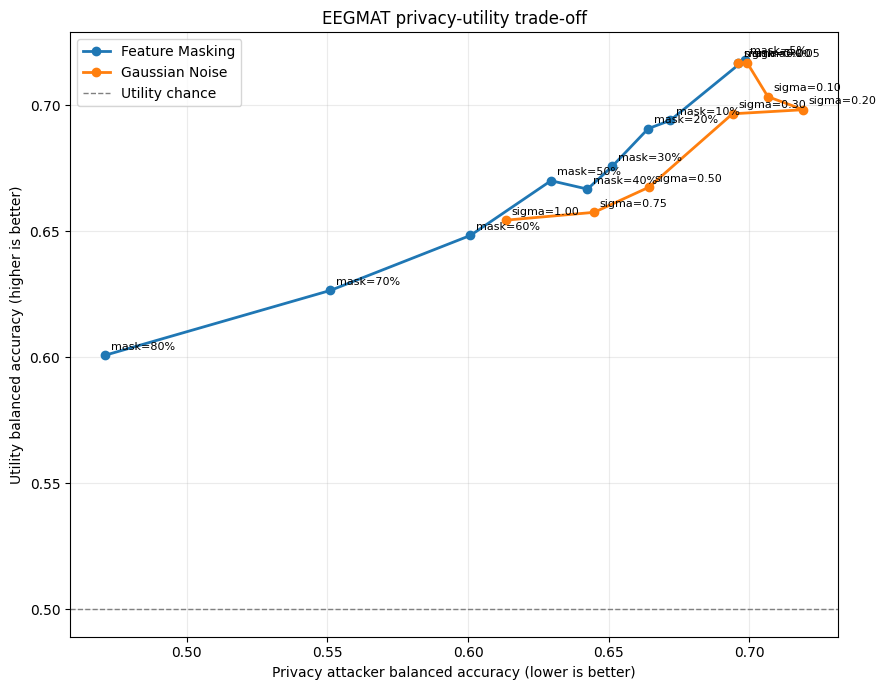

Saved detailed results: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_gaussian_feature_masking_detailed.csv
Saved summary: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_gaussian_feature_masking_summary.csv
Saved trade-off table: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_gaussian_feature_masking_tradeoff.csv
Saved feature rankings: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_feature_masking_rankings.csv
Saved figure: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_gaussian_feature_masking_tradeoff.png
Saved run metadata: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_gaussian_feature_masking_run.json


In [9]:
plt.figure(figsize=(9, 7))
for method, group in tradeoff.groupby("method"):
    ordered = group.sort_values("strength")
    plt.plot(
        ordered["balanced_accuracy_mean_privacy"],
        ordered["balanced_accuracy_mean_utility"],
        marker="o",
        linewidth=2,
        label=method.replace("_", " ").title(),
    )
    for row in ordered.itertuples(index=False):
        plt.annotate(
            row.strength_label,
            (row.balanced_accuracy_mean_privacy,
             row.balanced_accuracy_mean_utility),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )

plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Utility chance")
plt.xlabel("Privacy attacker balanced accuracy (lower is better)")
plt.ylabel("Utility balanced accuracy (higher is better)")
plt.title("EEGMAT privacy-utility trade-off")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_FILE, dpi=200, bbox_inches="tight")
plt.show()

run_summary = {
    "dataset": "EEGMAT",
    "input": "clean EEG-only 1-80 Hz baseline",
    "n_subjects": int(metadata["subject_id"].nunique()),
    "n_windows": int(len(metadata)),
    "n_channels": int(X_raw.shape[1]),
    "n_features": int(X_clean_features.shape[1]),
    "utility_model": "Random Forest, 500 trees",
    "privacy_attacker": "standardized Logistic Regression",
    "protocol": "five outer subject folds; matched utility and privacy evaluation",
    "gaussian_noise_sigmas": NOISE_SIGMAS,
    "feature_mask_percentages": MASK_PERCENTAGES,
    "files": {
        "detailed": str(DETAIL_FILE),
        "summary": str(SUMMARY_FILE),
        "tradeoff": str(TRADEOFF_FILE),
        "feature_rankings": str(RANKING_FILE),
        "figure": str(FIGURE_FILE),
    },
}

with open(RUN_FILE, "w") as handle:
    json.dump(run_summary, handle, indent=2)

print("Saved detailed results:", DETAIL_FILE)
print("Saved summary:", SUMMARY_FILE)
print("Saved trade-off table:", TRADEOFF_FILE)
print("Saved feature rankings:", RANKING_FILE)
print("Saved figure:", FIGURE_FILE)
print("Saved run metadata:", RUN_FILE)